# Project Architecture

This project was designed as a complete analytical pipeline rather than a standalone notebook workflow.

The dataset is first cleaned and validated in Python, transformed into an analytical star-schema structure, and then loaded into PostgreSQL using a custom ETL pipeline.

The project separates:

* Raw data ingestion
* Data cleaning and validation
* Schema transformation
* Database loading
* Analytical querying

This modular structure improves maintainability, scalability, and reproducibility.

---


# ETL Pipeline Overview

The ETL process is implemented through dedicated Python modules:

* `etl_load.py`
* `db.py`

## ETL Workflow

The pipeline performs the following steps:

1. Load the raw CSV dataset.
2. Clean and standardize all columns.
3. Validate dates, categorical values, and numeric fields.
4. Parse complex text fields such as mission duration and partner agencies.
5. Build dimension tables and fact tables.
6. Create bridge tables for many-to-many relationships.
7. Load the cleaned schema into PostgreSQL.
8. Apply indexes for analytical query performance.

---

# Database Design

The original dataset was provided as a flat file.

To improve analytical usability and reduce structural nulls, the data was transformed into a star-schema warehouse design.

## Schema Components

### Fact Table

* `fact_missions`

Contains measurable mission-level attributes such as:

* mission status
* duration
* cost
* mission category

### Dimension Tables

* `dim_date`
* `dim_agency`
* `dim_launch`
* `dim_mission_meta`

These tables isolate descriptive attributes and reduce redundancy.

### Bridge Tables

* `bridge_crew`
* `bridge_partners`

These tables resolve many-to-many relationships between missions, crew members, and partner agencies.

---

# Data Cleaning & Validation

## Initial Data Inspection

After loading the dataset, an initial inspection was performed to evaluate:

* data types
* missing values
* duplicate records
* categorical consistency
* numerical distributions

### Initial Findings

* Most columns were initially loaded as string (`object`) data types.
* `cost_usd_million` and `duration` required parsing and conversion to numeric formats.
* Several null values were identified as structural rather than missing data.

---


# Duplicate Validation

The dataset was checked for duplicate rows and identifier consistency.

## Findings

* No duplicate rows were found.
* No duplicate mission IDs were detected.
* Duplicate mission names were present across different agencies.

After inspection, these records were determined to represent separate missions rather than duplicated entries.

## Actions Performed

* No rows were removed during duplicate validation.

---

# Missing Value Assessment

Null values were analyzed to distinguish true missing data from structural nulls caused by the flat-file format.

## Structural Null Examples

* `failure_reason` is empty for successful missions.
* `end_date` is empty for ongoing missions.
* `key_achievement` is often empty for failed missions.

These null values are logically valid and contain informational meaning.

## Conclusion

No imputation was performed for structural nulls.

Instead, the schema was redesigned to better separate mission metadata from mission facts.

---

# Categorical Validation

Categorical columns were reviewed using frequency distributions and value counts.

## Findings

* No spelling inconsistencies were identified.
* No category formatting inconsistencies were found.
* Allowed-value validation confirmed category integrity across major columns.

---

# Numerical Distribution Review

The distributions of mission cost and duration were inspected.

## Findings

* Mission duration displayed a reasonable distribution.
* Mission cost displayed a potentially unusual distribution pattern.

This will be investigated further during exploratory data analysis.

---

# Temporal Validation

Date columns were validated for chronological consistency.

## Findings

A total of 235 rows contained an `end_date` earlier than the corresponding `launch_date`.

These records violate temporal logic and were treated as invalid observations.

## Actions Performed

* Removed all records where `end_date < launch_date`.

---


# Final Output

The final cleaned dataset was successfully transformed into a PostgreSQL star-schema warehouse and prepared for:

* Exploratory Data Analysis
* Statistical Analysis
* Machine Learning
* Time Series Analysis
* SQL Analytics
* Dashboard Development

## Environment Setup

This section imports the required libraries, configures the notebook environment, and initializes logging and database utilities used throughout the project.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

from src.logger import setup_logging, get_logger
from src.db import load_missions_with_meta, health_check
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



In [2]:
setup_logging()
log = get_logger(__name__)

log.info("Starting data cleaning notebook")

17:32:52  INFO      Logging initialised — file: F:\projects\space_mission_analysis\notebooks\logs\space_missions.log
17:32:52  INFO      Starting data cleaning notebook


## Database Validation

Before beginning the analysis, a database health check is performed to verify that all dimension, fact, and bridge tables were loaded successfully into PostgreSQL.

In [3]:
setup_logging()
log = get_logger(__name__)

health_check()


17:32:52  INFO      ── Database Health Check ─────────────────────
17:32:52  INFO      Database engine initialised — localhost:5433/space_missions
17:32:52  INFO        dim_date                   12,081 rows
17:32:52  INFO        dim_agency                     27 rows
17:32:52  INFO        dim_launch                    139 rows
17:32:52  INFO        dim_mission_meta           10,500 rows
17:32:52  INFO        fact_missions              10,500 rows
17:32:52  INFO        bridge_crew                11,789 rows
17:32:52  INFO        bridge_partners             4,336 rows
17:32:52  INFO      Health check passed — all tables populated.
17:32:52  INFO      ──────────────────────────────────────────────


## Load raw Dataset

The  dataset is loaded from PostgreSQL using the custom database helper functions defined in `db.py`.

The loaded dataset combines:

- fact tables
- dimension tables
- mission metadata

into a single analytical dataframe suitable for validation and exploratory analysis.

In [4]:
df = load_missions_with_meta()
df.shape

17:32:52  INFO      load_missions_with_meta → 10,500 rows


(10500, 28)

## Preview Dataset Structure

The first few rows are inspected to verify that the schema loaded correctly and to understand the structure of the analytical dataset.

In [5]:
df.head()

,mission_id,mission_name,program_type,mission_category,sub_category,destination,status,mission_phase,crew_type,data_returned,...,launch_date,launch_year,launch_decade,end_date,end_year,end_decade,objective,key_achievement,mission_outcome_detail,reference_url
0,SP-10332,SpaceX Asteroid Mission 10332,Sounding Rocket,Asteroid,Impactor,Asteroid,Success,Past,Uncrewed,Partial,...,1957-01-01,1957,1950s,1964-07-07,1964.0,1960s,Orbital mechanics experiment for future missions,Achieved supersonic retropropulsion,Achieved orbit insertion on first attempt,https://www.spacex.com/missions/spacex-asteroi...
1,CN-09787,CNES Sounding Rocket Mission 9787,Satellite,Sounding Rocket,Atmospheric Study,Sounding Rocket,Partial Success,Past,Crewed,No,...,1957-01-05,1957,1950s,1958-09-04,1958.0,1950s,Space debris monitoring and removal,First images returned from target destination,Captured highest resolution images to date,https://cnes.fr/mission/cnes-sounding-rocket-m...
2,JA-03767,JAXA Mars Mission 3767,Robotic,Mars,Sample Return,Mars,Success,Past,Crewed,Partial,...,1957-01-14,1957,1950s,1957-05-12,1957.0,1950s,Black hole imaging and stellar cataloguing,Partial success - secondary objectives met,Collected and returned surface samples,https://www.jaxa.jp/missions/jaxa-mars-mission...
3,ES-09538,ESA Technology Demo Mission 9538,Human Spaceflight,Technology Demo,Propulsion Test,Technology Demo,Partial Success,Past,Uncrewed,Partial,...,1957-01-16,1957,1950s,1958-02-17,1958.0,1950s,Solar wind and coronal mass ejection monitoring,Landed successfully within target zone,Broke distance record for agency,https://www.esa.int/Science_Exploration/esa-te...
4,CN-10042,CNSA Technology Demo Mission 10042,Telescope,Technology Demo,In-Orbit Servicing,Technology Demo,Success,Past,Crewed,Partial,...,1957-01-18,1957,1950s,1962-11-02,1962.0,1960s,Lunar surface exploration and soil sample coll...,Collected and returned surface samples,Discovered new geological features,http://www.cnsa.gov.cn/mission/cnsa-technology...


## Initial Data Inspection

The dataset structure is inspected to evaluate:

- data types
- column completeness
- memory usage
- general schema integrity

Special attention is given to numerical and datetime fields that may require additional validation.

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10500 entries, 0 to 10499
Data columns (total 28 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   mission_id              10500 non-null  object 
 1   mission_name            10500 non-null  object 
 2   program_type            10500 non-null  object 
 3   mission_category        10500 non-null  object 
 4   sub_category            10500 non-null  object 
 5   destination             10500 non-null  object 
 6   status                  10500 non-null  object 
 7   mission_phase           10500 non-null  object 
 8   crew_type               10500 non-null  object 
 9   data_returned           8940 non-null   object 
 10  failure_reason          1161 non-null   object 
 11  cost_usd_billion        10500 non-null  object 
 12  duration_days           5561 non-null   object 
 13  agency_name             10500 non-null  object 
 14  country_region          10500 non-null

## Descriptive Statistics

Descriptive statistics are reviewed to identify:

- unexpected distributions
- unusual categorical frequencies
- possible data quality issues
- early signs of skewness or outliers

Because many columns are categorical, the output primarily highlights the most common values across the dataset.

In [7]:
df.describe(include='all')

,mission_id,mission_name,program_type,mission_category,sub_category,destination,status,mission_phase,crew_type,data_returned,...,launch_date,launch_year,launch_decade,end_date,end_year,end_decade,objective,key_achievement,mission_outcome_detail,reference_url
count,10500,10500,10500,10500,10500,10500,10500,10500,10500,8940,...,10500,10500.000000,10500,5796,5796.000000,5796,10500,10179,10500,10500
unique,10500,10477,7,19,66,19,5,3,2,3,...,8496,NaN,9,5067,NaN,8,25,34,25,10497
top,SP-10332,Crew-10,Robotic,Mercury,Flyby,Mercury,Success,Past,Uncrewed,Partial,...,2023-01-04,NaN,2020s,2022-11-11,NaN,2010s,Asteroid composition and deflection study,Planned - objectives to be confirmed post-launch,First images returned from target destination,https://www.nasa.gov/mission/mars-sample-return
freq,1,2,1554,597,1196,597,4314,6835,7863,3094,...,8,NaN,3044,5,NaN,1062,459,1871,470,2
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,2002.627619,NaN,NaN,1996.578847,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,23.350006,NaN,NaN,18.516019,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,1957.000000,NaN,NaN,1957.000000,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,1982.000000,NaN,NaN,1981.000000,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,2008.000000,NaN,NaN,1998.000000,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,2023.000000,NaN,NaN,2014.000000,NaN,NaN,NaN,NaN,NaN


## Numerical Validation

The `cost_usd_million` and `duration_days` columns are analyzed after conversion to numeric types.

Initial inspection shows:

- the mean and median values are relatively close
- no extreme outliers are immediately visible
- the overall distributions appear reasonable during the cleaning phase

Further distribution analysis will be performed during exploratory analysis.

In [8]:
df[["cost_usd_billion", "duration_days"]].describe(
    percentiles=[.25, .5, .75, .90, .95, .99]
)

,cost_usd_billion,duration_days
count,10500,5561
unique,1498,419
top,3.95,474.82
freq,18,58


## Duplicate Mission Name Analysis

Mission names are checked for duplication to determine whether duplicate records exist within the dataset.

In [9]:
df['mission_name'].duplicated().sum()

np.int64(23)

## Duplicate ID Validation

Mission identifiers are validated to confirm that each mission record contains a unique primary key.

In [10]:
df['mission_id'].duplicated().sum()

np.int64(0)

## Investigating Duplicate Mission Names

Duplicate mission names are inspected in detail.

The review shows that duplicated mission names belong to different agencies, meaning the records represent separate missions rather than duplicated observations.

As a result, these records are retained.

In [11]:
d= df[df['mission_name'].duplicated(keep=False)].sort_values('mission_name')

## Missing Value Assessment

Null values are evaluated to distinguish:

- true missing data
- structural nulls caused by the flat-file design

Examples of structural nulls include:

- `failure_reason` for successful missions
- `end_date` for ongoing missions
- `key_achievement` for failed missions

These values contain meaningful business logic and are therefore preserved.

In [12]:
null_counts = df.isnull().sum()
null_pct = (null_counts / len(df)*100).round(2)
null_summary = pd.DataFrame({'null_count': null_counts, 'null_pct': null_pct}).query('null_count > 0').sort_values('null_pct', ascending=False)
print(null_summary) 

                 null_count  null_pct
failure_reason         9339     88.94
duration_days          4939     47.04
end_date               4704     44.80
end_decade             4704     44.80
end_year               4704     44.80
data_returned          1560     14.86
key_achievement         321      3.06


## Missing Value Visualization

A visual summary of missing values is created to identify patterns and confirm that the null values primarily reflect structural characteristics rather than data quality failures.

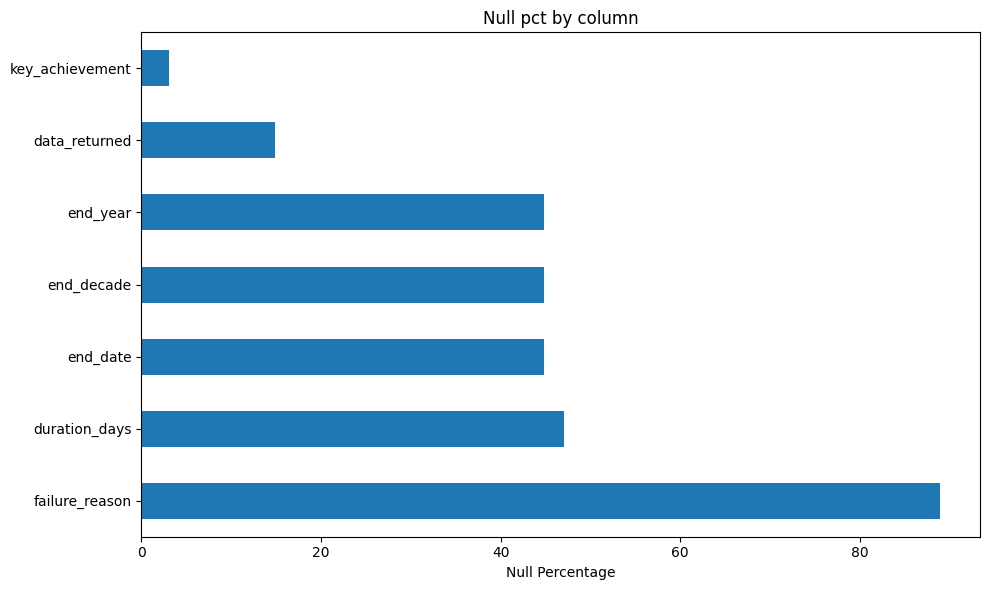

In [13]:
fig, ax = plt.subplots(figsize=(10,6))
null_summary['null_pct'].plot(kind = 'barh', ax=ax)
ax.set_title('Null pct by column')
ax.set_xlabel('Null Percentage')
fig.tight_layout()
plt.show()

## Categorical Consistency Validation

Categorical columns are reviewed using value counts to identify:

- spelling inconsistencies
- formatting issues
- unexpected category labels

The inspection confirms that the categorical fields are standardized and internally consistent.

In [14]:
cat_cols = ["status", "mission_phase", "crew_type", "agency_type",
            "program_type", "mission_category", "data_returned"]

for col in cat_cols:
    print(f"\n--- {col} ---")
    print(df[col].value_counts(dropna=False))


--- status ---
status
Success            4314
Ongoing            3144
Upcoming           1560
Failed              909
Partial Success     573
Name: count, dtype: int64

--- mission_phase ---
mission_phase
Past       6835
Ongoing    2105
Future     1560
Name: count, dtype: int64

--- crew_type ---
crew_type
Uncrewed    7863
Crewed      2637
Name: count, dtype: int64

--- agency_type ---
agency_type
Government    8689
Private       1811
Name: count, dtype: int64

--- program_type ---
program_type
Robotic              1554
Satellite            1537
Commercial           1511
Telescope            1485
Human Spaceflight    1485
Sounding Rocket      1481
Technology Demo      1447
Name: count, dtype: int64

--- mission_category ---
mission_category
Mercury                    597
Deep Space                 582
SmallSat                   579
Saturn                     575
Moon                       571
Mars                       564
Communication Satellite    563
Telescope                  559


## Numeric Type Conversion

The `cost_usd_billion` column is explicitly converted to a numeric type to ensure compatibility with statistical analysis, machine learning workflows, and visualization libraries.

In [16]:
df['cost_usd_billion'] = pd.to_numeric(df['cost_usd_billion'], errors='coerce')
df['duration_days'] = pd.to_numeric(df['duration_days'], errors='coerce')

## Distribution Review

The distributions of mission cost and duration are visualized using histograms.

### Findings

- Mission duration appears reasonably distributed.
- Mission cost displays a potentially unusual pattern.

This observation will be investigated further during the Exploratory Data Analysis stage.

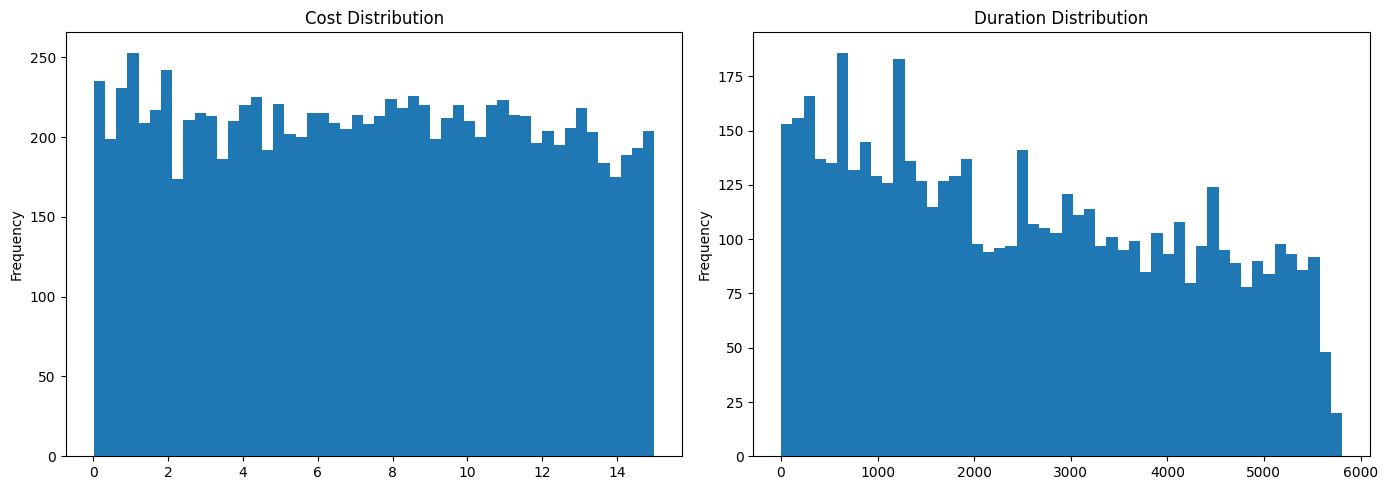

In [17]:
fig,axes = plt.subplots(1,2, figsize=(14,5))
df['cost_usd_billion'].plot(kind='hist', bins=50, ax=axes[0])
axes[0].set_title('Cost Distribution')
df['duration_days'].plot(kind='hist', bins=50, ax=axes[1])
axes[1].set_title('Duration Distribution')
plt.tight_layout()
plt.show()

## Temporal Validation

Date fields are validated for chronological consistency.

### Findings

A subset of missions contains an `end_date` earlier than the corresponding `launch_date`.

These observations violate temporal logic and are treated as invalid records during the cleaning process.

In [ ]:
df[df['end_date'].notna() & (df['end_date'] < df['launch_date'])]

,mission_id,mission_name,program_type,mission_category,sub_category,destination,status,mission_phase,crew_type,data_returned,...,launch_decade,end_date,end_year,end_quarter,end_month,end_decade,objective,key_achievement,mission_outcome_detail,reference_url
84,SP-05231,SpaceX Telescope Mission 5231,Human Spaceflight,Telescope,Optical,Telescope,Failed,Past,Uncrewed,Yes,...,1950s,1957-07-23,1957.0,3.0,7.0,1950s,Heliosphere boundary exploration,Communication failure post-separation,Landed successfully within target zone,https://www.spacex.com/missions/spacex-telesco...
181,CN-02601,CNSA Saturn Mission 2601,Technology Demo,Saturn,Probe,Saturn,Partial Success,Past,Uncrewed,Partial,...,1950s,1958-03-31,1958.0,1.0,3.0,1950s,Next-generation communication satellite deploy...,First crewed landing at destination,Failed to achieve orbit due to launch vehicle ...,http://www.cnsa.gov.cn/mission/cnsa-saturn-mis...
273,BL-10163,Blue Origin Moon Mission 10163,Technology Demo,Moon,Flyby,Moon,Success,Past,Crewed,Yes,...,1950s,1959-03-18,1959.0,1.0,3.0,1950s,Earth observation for disaster management,Exceeded planned science return by 3x,Historic first for agency and country,https://www.blueorigin.com/missions/blue-origi...
350,DL-08878,DLR Communication Satellite Mission 8878,Robotic,Communication Satellite,Geostationary,Communication Satellite,Failed,Past,Uncrewed,No,...,1960s,1960-01-28,1960.0,1.0,1.0,1960s,Solar wind and coronal mass ejection monitoring,Launch vehicle upper stage malfunction,Broke distance record for agency,https://www.dlr.de/mission/dlr-communication-s...
439,CS-05729,CSA Sun/Solar Mission 5729,Telescope,Sun/Solar,Solar Observer,Sun/Solar,Success,Past,Crewed,Yes,...,1960s,1961-04-03,1961.0,2.0,4.0,1960s,Asteroid composition and deflection study,Planned - objectives to be confirmed post-launch,Planned - objectives to be confirmed post-launch,https://www.asc-csa.gc.ca/mission/csa-sun/sola...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7677,SP-05299,SpaceX Crewed Spaceflight Mission 5299,Commercial,Crewed Spaceflight,Moon Mission,Crewed Spaceflight,Success,Past,Uncrewed,Partial,...,2020s,2022-06-26,2022.0,2.0,6.0,2020s,Heliosphere boundary exploration,Failed to achieve orbit due to launch vehicle ...,Mission ongoing - data collection in progress,https://www.spacex.com/missions/spacex-crewed-...
7682,JA-09428,JAXA Saturn Mission 9428,Robotic,Saturn,Orbiter,Saturn,Success,Past,Uncrewed,No,...,2020s,2022-04-03,2022.0,2.0,4.0,2020s,High-resolution Earth surface mapping,Confirmed presence of subsurface water,Planned - objectives to be confirmed post-launch,https://www.jaxa.jp/missions/jaxa-saturn-missi...
7683,SP-03185,SpaceX Moon Mission 3185,Commercial,Moon,Flyby,Moon,Failed,Past,Crewed,Partial,...,2020s,2022-08-06,2022.0,3.0,8.0,2020s,High-resolution Earth surface mapping,Launch vehicle upper stage malfunction,Achieved orbit insertion on first attempt,https://www.spacex.com/missions/spacex-moon-mi...
7686,SP-06792,SpaceX CubeSat Mission 6792,Human Spaceflight,CubeSat,16U CubeSat,CubeSat,Success,Past,Crewed,No,...,2020s,2022-08-22,2022.0,3.0,8.0,2020s,Commercial crew certification flight,Planned - objectives to be confirmed post-launch,Extended mission beyond original timeline,https://www.spacex.com/missions/spacex-cubesat...
